In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
data= pd.read_csv('ds_salaries.csv')

In [4]:
data.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [5]:
data.shape


(607, 12)

In [6]:
data.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [7]:
data.dtypes

Unnamed: 0             int64
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

#Data cleaning

In [8]:
#Remove first column
data.drop(['Unnamed: 0'],axis=1,inplace=True) #axis=1 says its a column


In [9]:
# drop salary and salry currency as salary is in usd
data.drop(columns=['salary_currency','salary'],inplace=True)

In [10]:
data.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_in_usd', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size'],
      dtype='object')

#replace feature value for better understanding


In [11]:
print(data['experience_level'].unique())
print(data['employment_type'].unique())
print(data['remote_ratio'].unique())
print(data['company_size'].unique())


['MI' 'SE' 'EN' 'EX']
['FT' 'CT' 'PT' 'FL']
[  0  50 100]
['L' 'S' 'M']


In [12]:
# Experience Level
data['experience_level'] = data['experience_level'].map({
    'EN': 'Entry Level',
    'MI': 'Mid Level',
    'SE': 'Senior',
    'EX': 'Executive'
})

# Employment Type
data['employment_type'] = data['employment_type'].map({
    'PT': 'Part-time',
    'FT': 'Full-time',
    'CT': 'Contract',
    'FL': 'Freelance'
})

# Remote Ratio
data['remote_ratio'] = data['remote_ratio'].map({
    0: 'No Remote',
    50: 'Partially Remote',
    100: 'Fully Remote'
})

# Company Size
data['company_size'] = data['company_size'].map({
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
})

In [13]:
#checking for null values
data.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [14]:
data.duplicated().sum()


42

In [15]:
# Remove duplicate records
data.drop_duplicates(inplace=True)


In [16]:
data.shape

(565, 9)

# univairate analysis

In [17]:
# # lets check target variable i.e. salary_in_usd
data['salary_in_usd'].describe()


count       565.000000
mean     110610.343363
std       72280.702792
min        2859.000000
25%       60757.000000
50%      100000.000000
75%      150000.000000
max      600000.000000
Name: salary_in_usd, dtype: float64

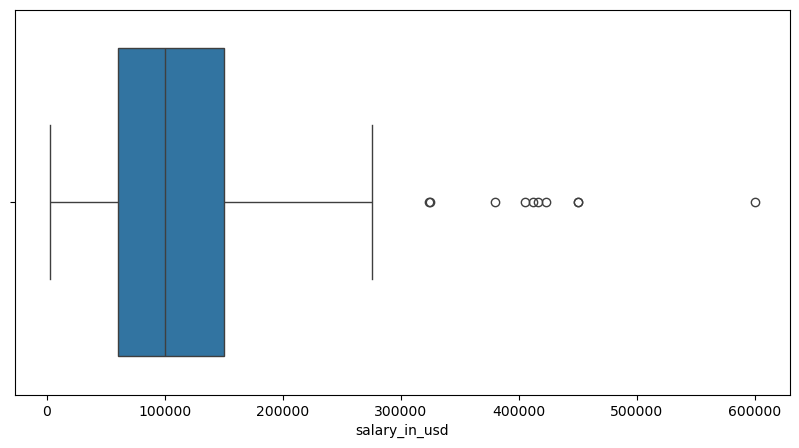

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data,x='salary_in_usd')
plt.show()

so salary above 30000 can be considered as outliers

In [19]:
# Lets remove records with outliers
data_outliers = data[data['salary_in_usd'] > 300000]
data_outliers.shape

(10, 9)

In [25]:
## Below function will plot countplot for the provided feature
def count_plot(feature):
 
 plt.figure(figsize=(15,5))
 ax = sns.countplot(data=data,x=feature)
 for p in ax.patches:
    ax.annotate('{}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()+2))
 plt.xticks(rotation=90)
 plt.show()

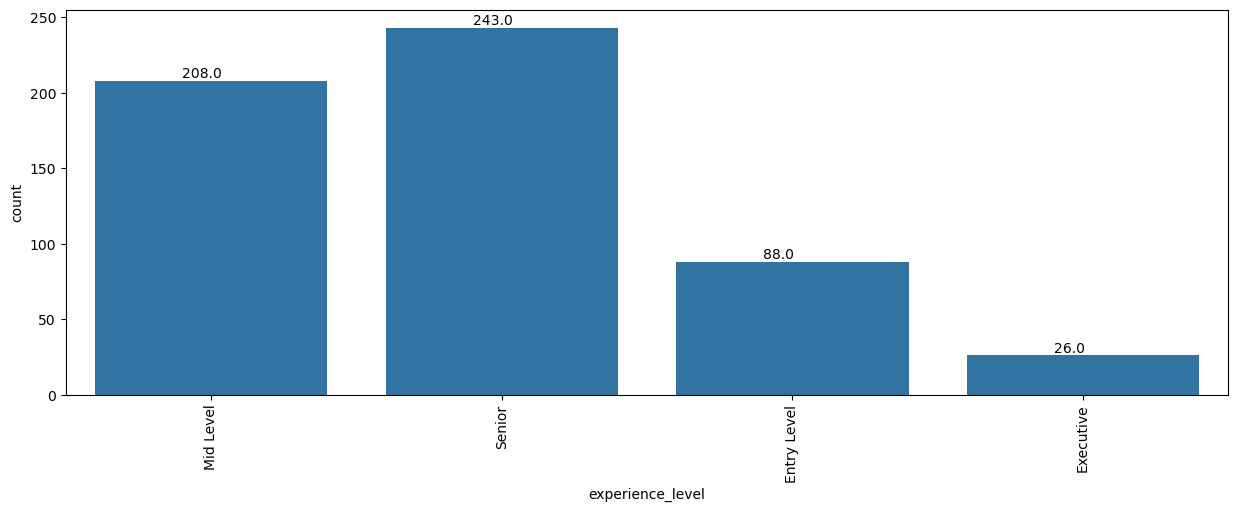

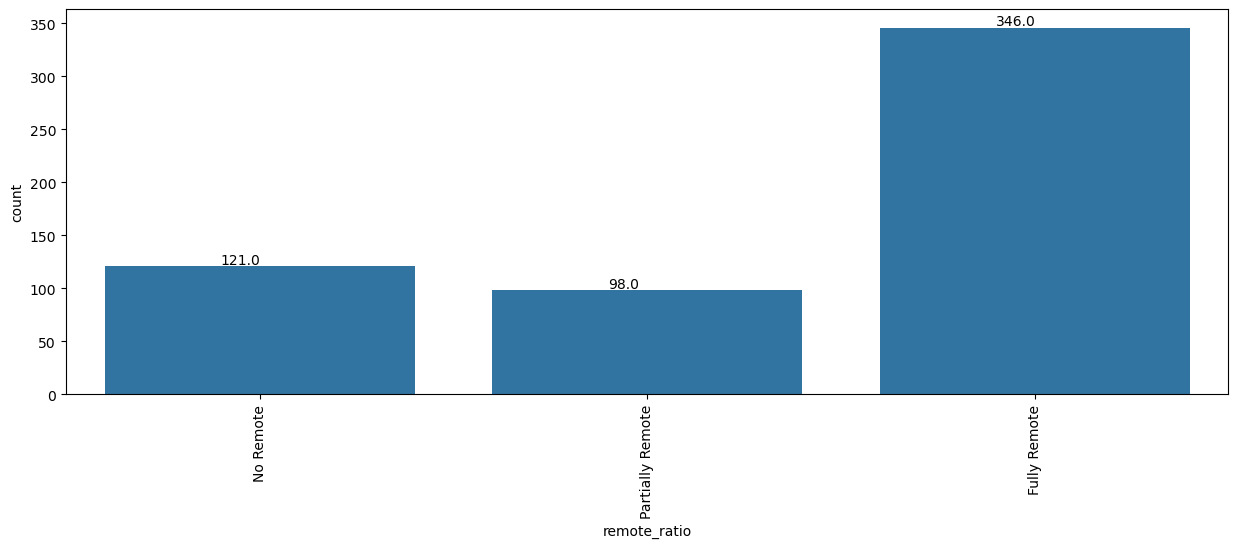

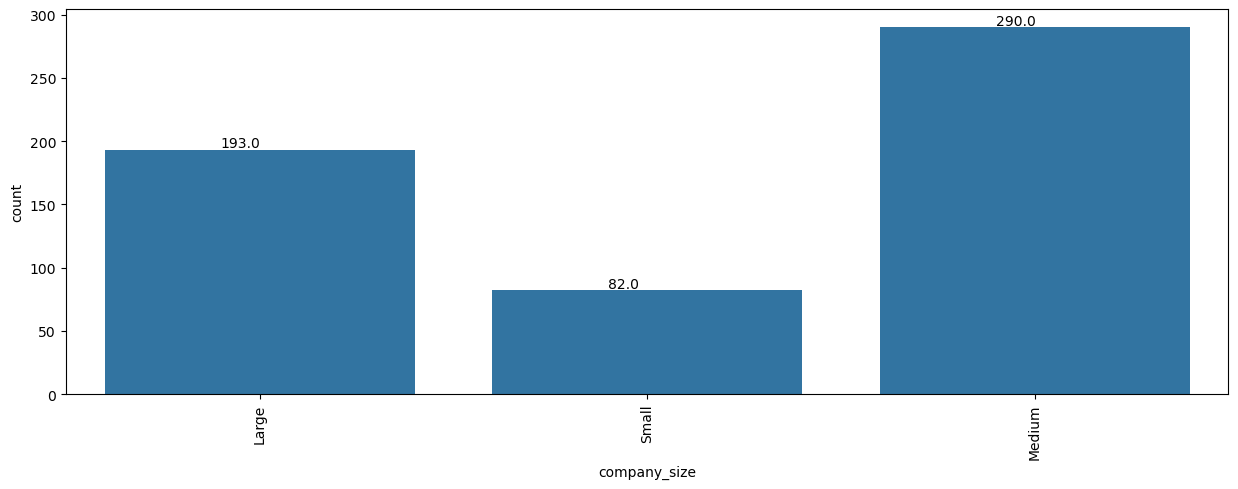

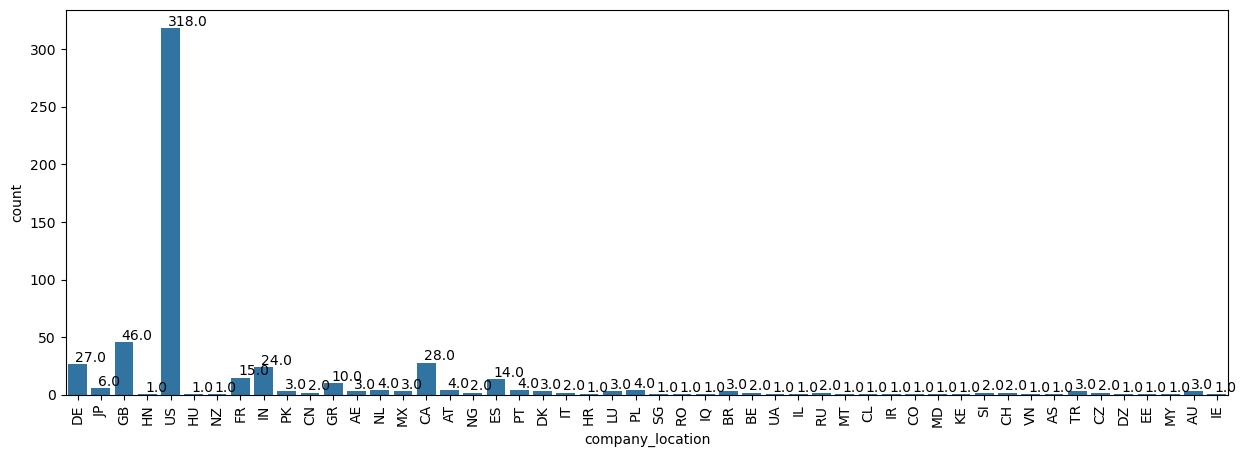

In [28]:
count_plot('experience_level')
count_plot('remote_ratio')
count_plot('company_size')
count_plot('company_location')


Multivariate Analysis

1. Which job title earns highest salary ?
2. What is the average salary for each experience level ?
3. What is the average salary for company size Large, Small and Medium ?
4. Does people working full time earns more than contract base employees ?
5. Is salary less for employee woking remotely than who comes to office ?
6. Which country pays more to the employees ?
7. What is the highest earning job in highest paying countries ?
8. What is the highest earning job titles working at expert level ?
9. What is the highest earning job titles working at senioir level ?
10. Has salary of data science job roles increased over the passing years ?
11. What is the trend of salary paid by medium size company over the passing years ?
12. What is the trend of salary paid by large size company over the passing years ?
13. What is the trend of salary paid by medium size company over the passing years ?


In [30]:
def box_plot(x, y, data, title):
    
    # Set the figure size
    plt.figure(figsize=(10, 8))
    
    # Calculate the mean of y for each category in x
    sals_mean = data.groupby([x])[y].mean()
    
    # Plot the boxplot
    ax = sns.boxplot(data=data, y=y, x=x)
    
    # Offset so the mean label doesnt overlap with the median line
    vertical_offset_mean = data[y].median() * 0.05
    
    # Loop through each x category label on the plot
    for i, xtick in enumerate(ax.get_xticklabels(which='major')):
        
        # Annotate each box with the mean value
        ax.text(
            i,                                                    # x position of label
            sals_mean[xtick.get_text()] + vertical_offset_mean,  # y position of label
            f"Mean: {sals_mean[xtick.get_text()]:.0f}",          # label text
            horizontalalignment='center',                          # center the text
            size='small',                                          # font size
            color='w',                                             # white color
            weight='semibold'                                      # bold text
        )
    
    # Set the title of the plot
    ax.set_title(title)
    
    # Display the plot
    plt.show()

In [31]:
def bar_plot(feature, data, title):
    
    # Calculate mean salary for each category in the feature column
    data = data.groupby(feature)['salary_in_usd'].mean()
    
    # Set the figure size
    plt.figure(figsize=(12, 16))
    
    # Plot horizontal bar chart
    ax = sns.barplot(x=data.values, y=data.index, color='pink')
    
    # Annotate each bar with the mean salary value
    for i, v in enumerate(data.values):
        ax.annotate(
            str(round(v, 2)),   # round to 2 decimal places
            xy=(v, i),          # position at end of bar
            va='center'         # vertically center the label
        )
    
    # Set axis labels and title
    ax.set_xlabel("Salary (USD)")
    ax.set_ylabel(feature)
    ax.set_title(title)
    
    # Display the plot
    plt.show()

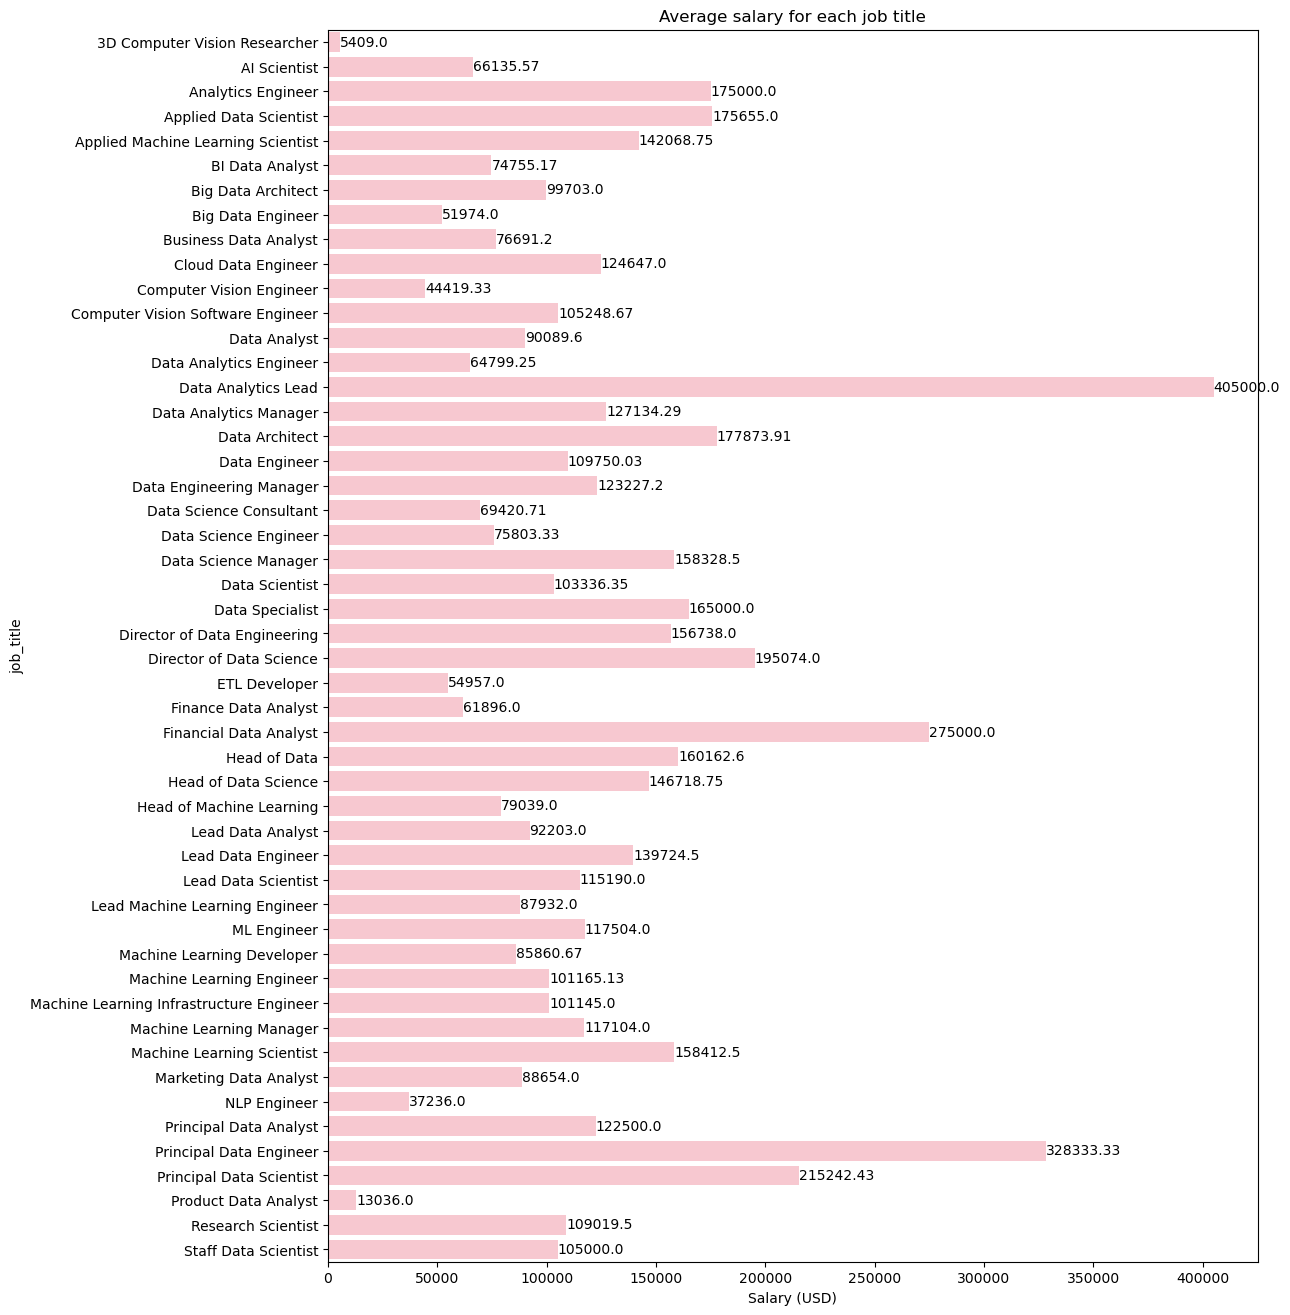

In [32]:
#job to earn high salary
bar_plot('job_title',data,'Average salary for each job title')

1. From the above figure we can see that top five highest earning jobs are Principal Data Engineer,
Principal Data Scientist, Data Architect, Analytics Engineer and Director of Data Science

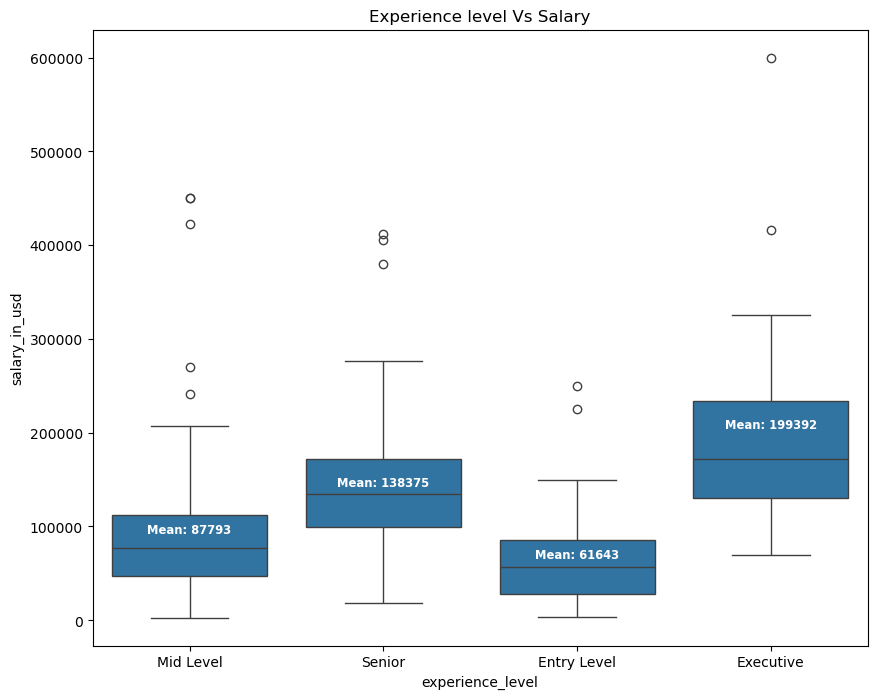

In [33]:
#2. What is the average salary for each experience level ?
box_plot('experience_level','salary_in_usd',data,"Experience level Vs Salary")

1. Average salary of expert is more than other experience levels.


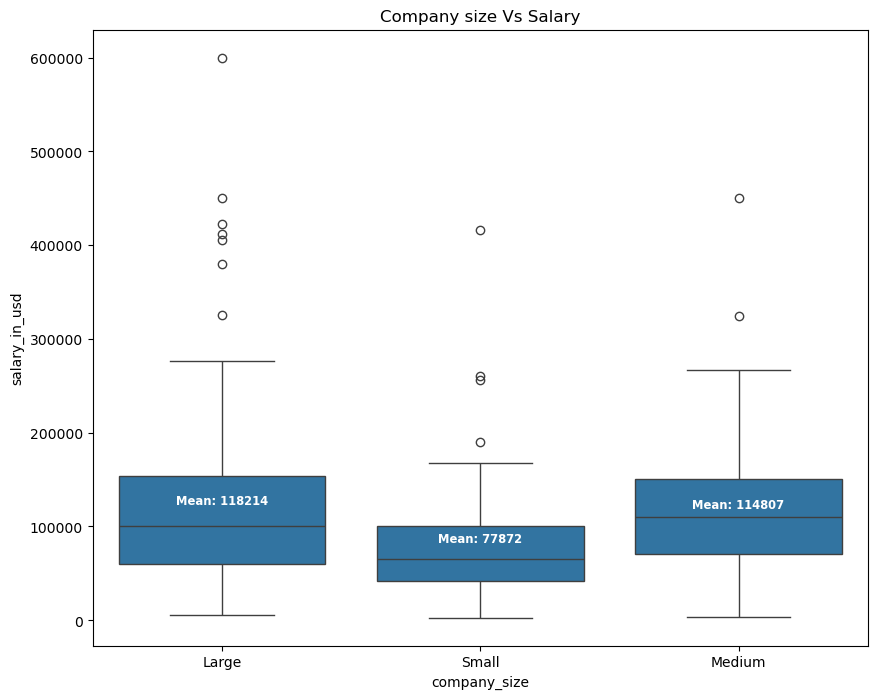

In [40]:
#3. What is the average salary for company size Large, Small and Medium ?
box_plot('company_size','salary_in_usd',data, 'Company size Vs Salary' )

1. On an average employees in large size company earns more than otehr size company.

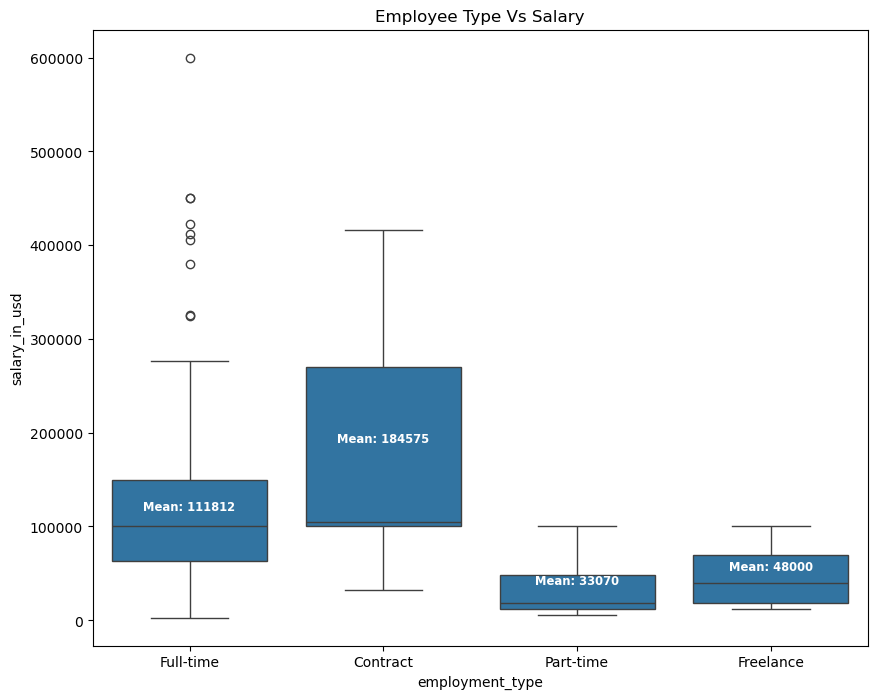

In [35]:
#4. Does people working full time earns more than contract base employees ?

box_plot('employment_type','salary_in_usd',data, 'Employee Type Vs Salary' )

1. From the above figure we can see that salary of contract base employee is more than full time
employee. But it might be impacted by outlier


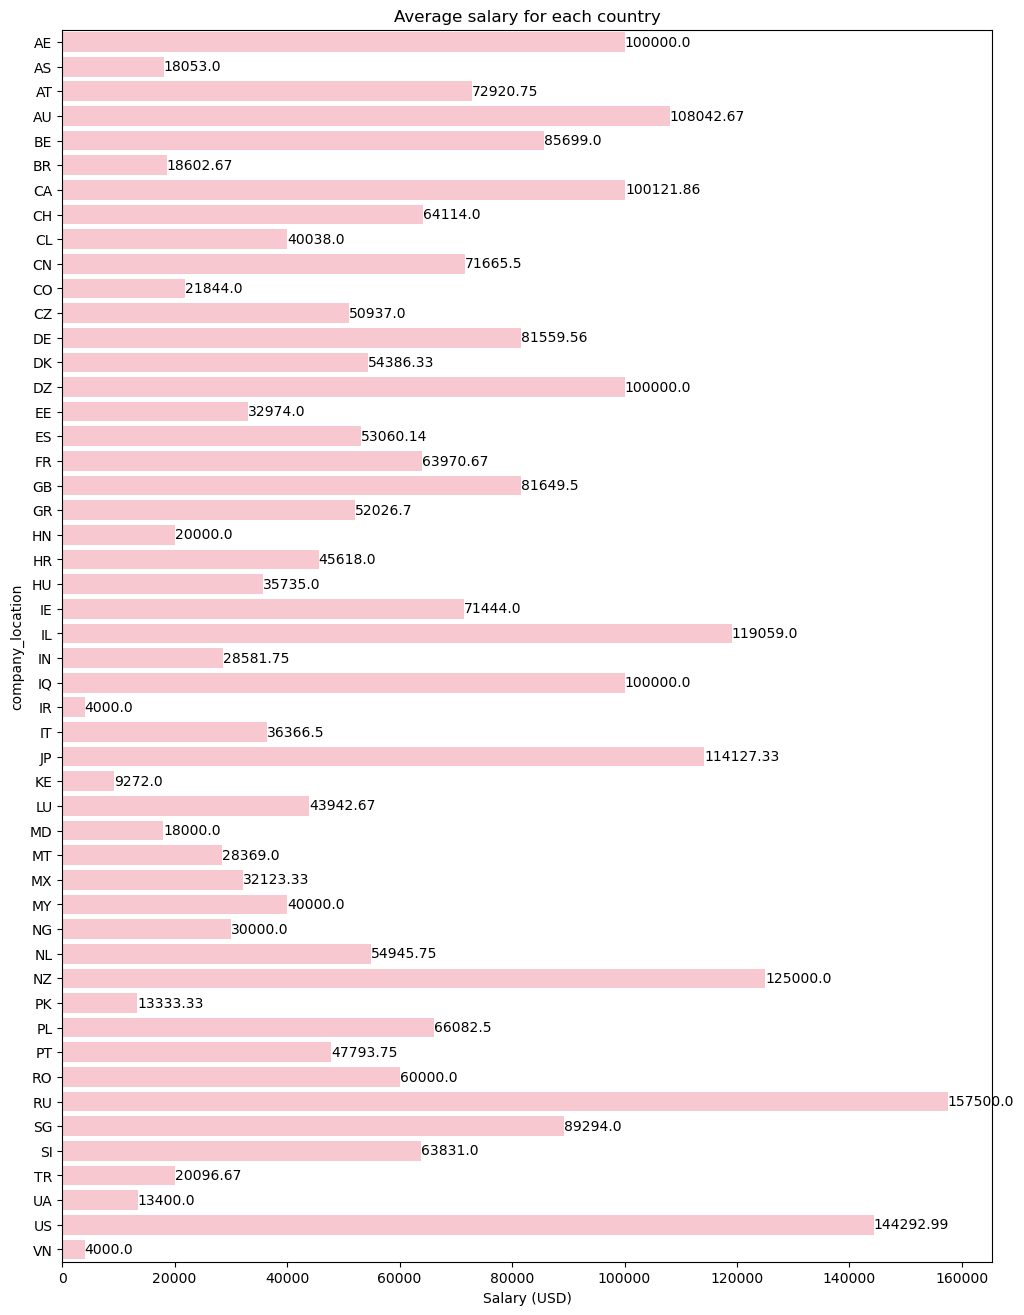

In [36]:
#6. Which country pays more to the employees ?

bar_plot('company_location',data,'Average salary for each country')

1. Top two highest paying countries are Russia and US.


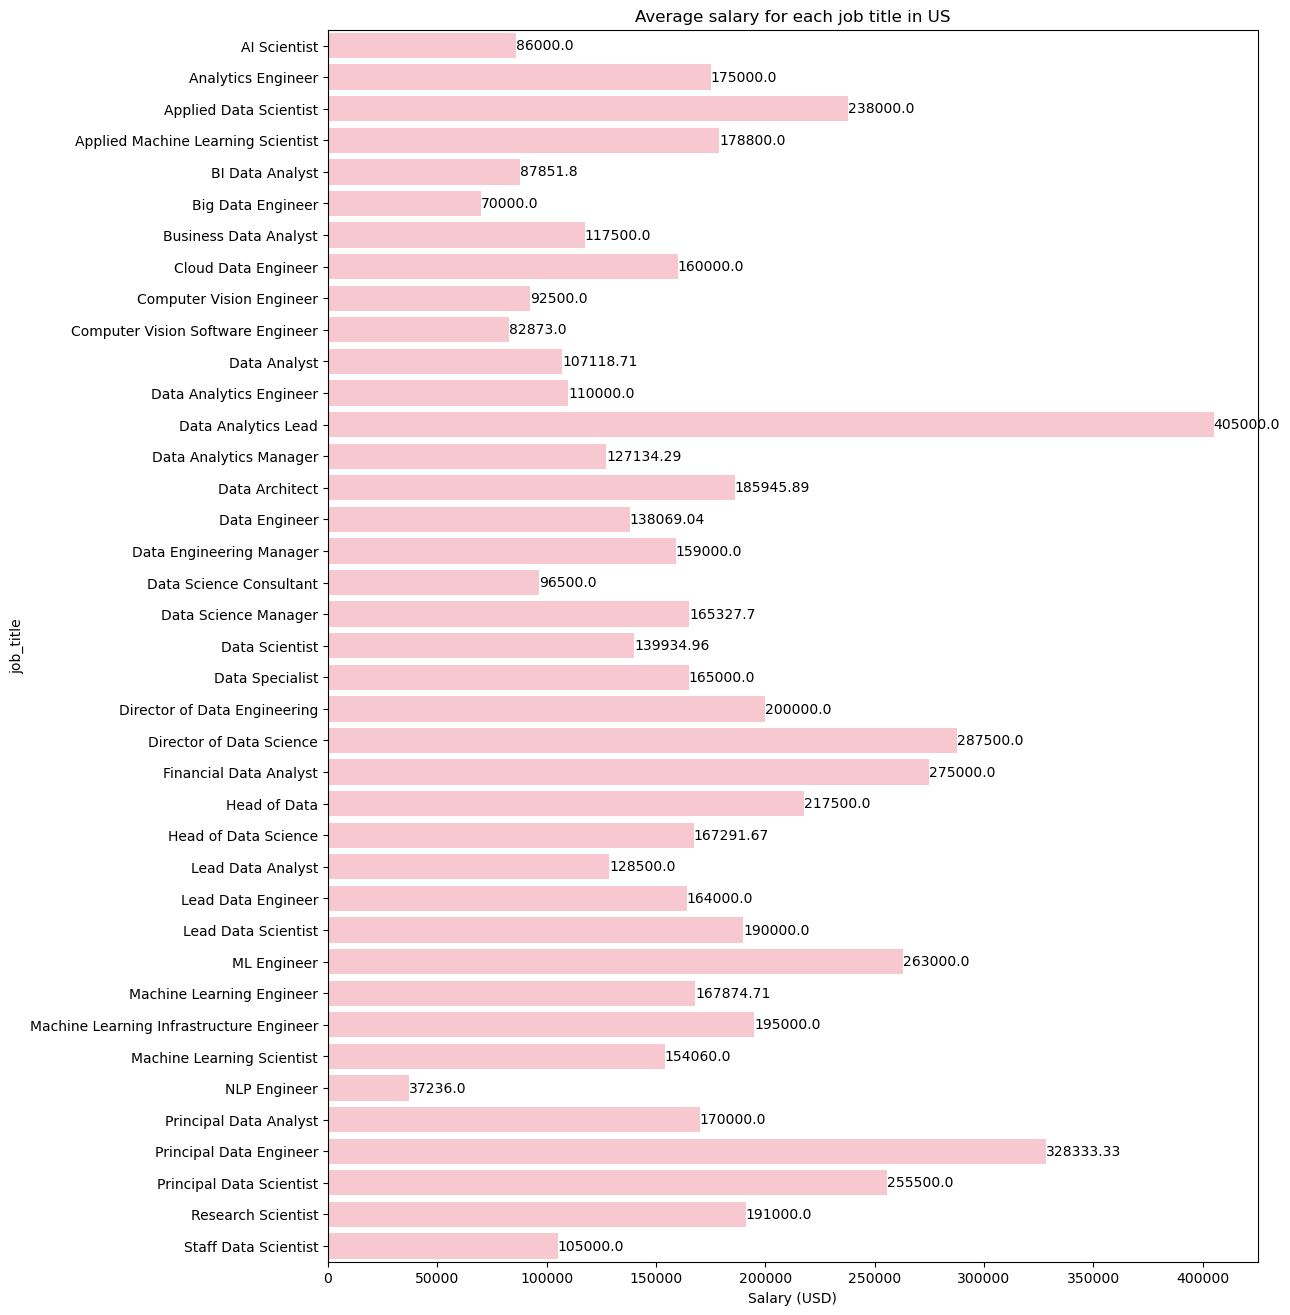

In [38]:
data_US = data[data['company_location']=='US']
# Plot job titles in US
bar_plot('job_title', data_US,'Average salary for each job title in US' )

In [51]:
#8. What is the average salary for highest earning job titles working at senior level ?

# Get the data for senior level roles
data_senior = data[data['experience_level']=='Senior']




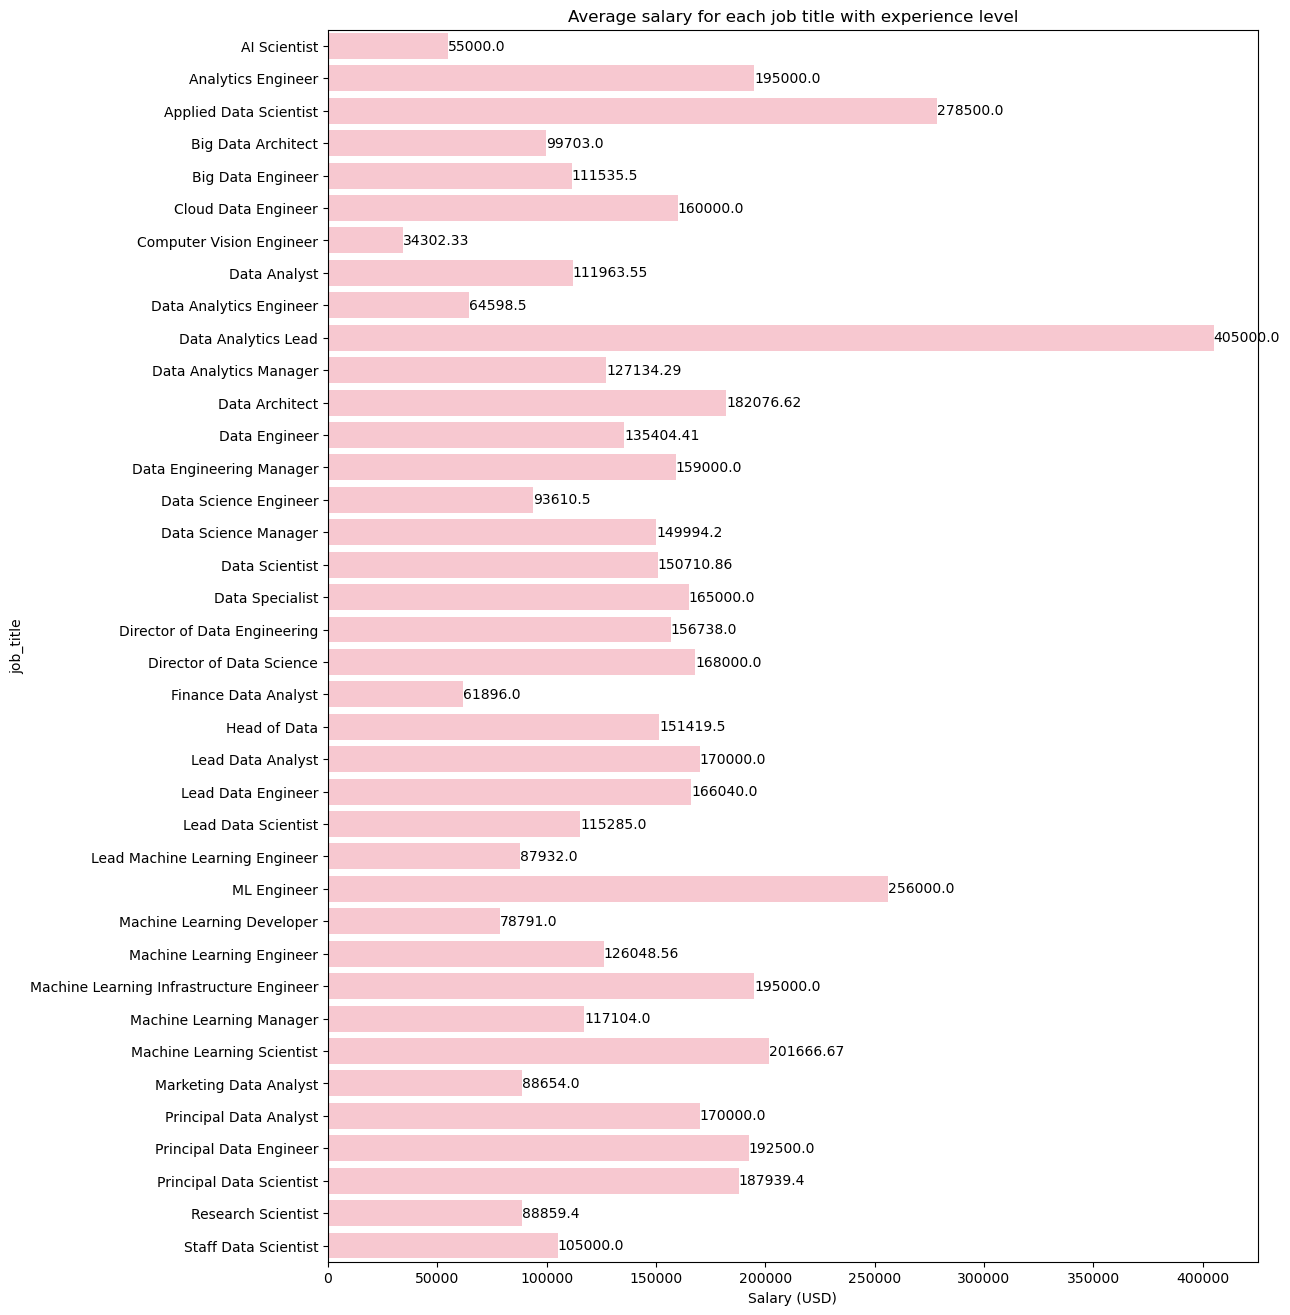

In [52]:
# Plot job titles working with experience level as expert
bar_plot('job_title',data_senior,"Average salary for each job title with experience level")

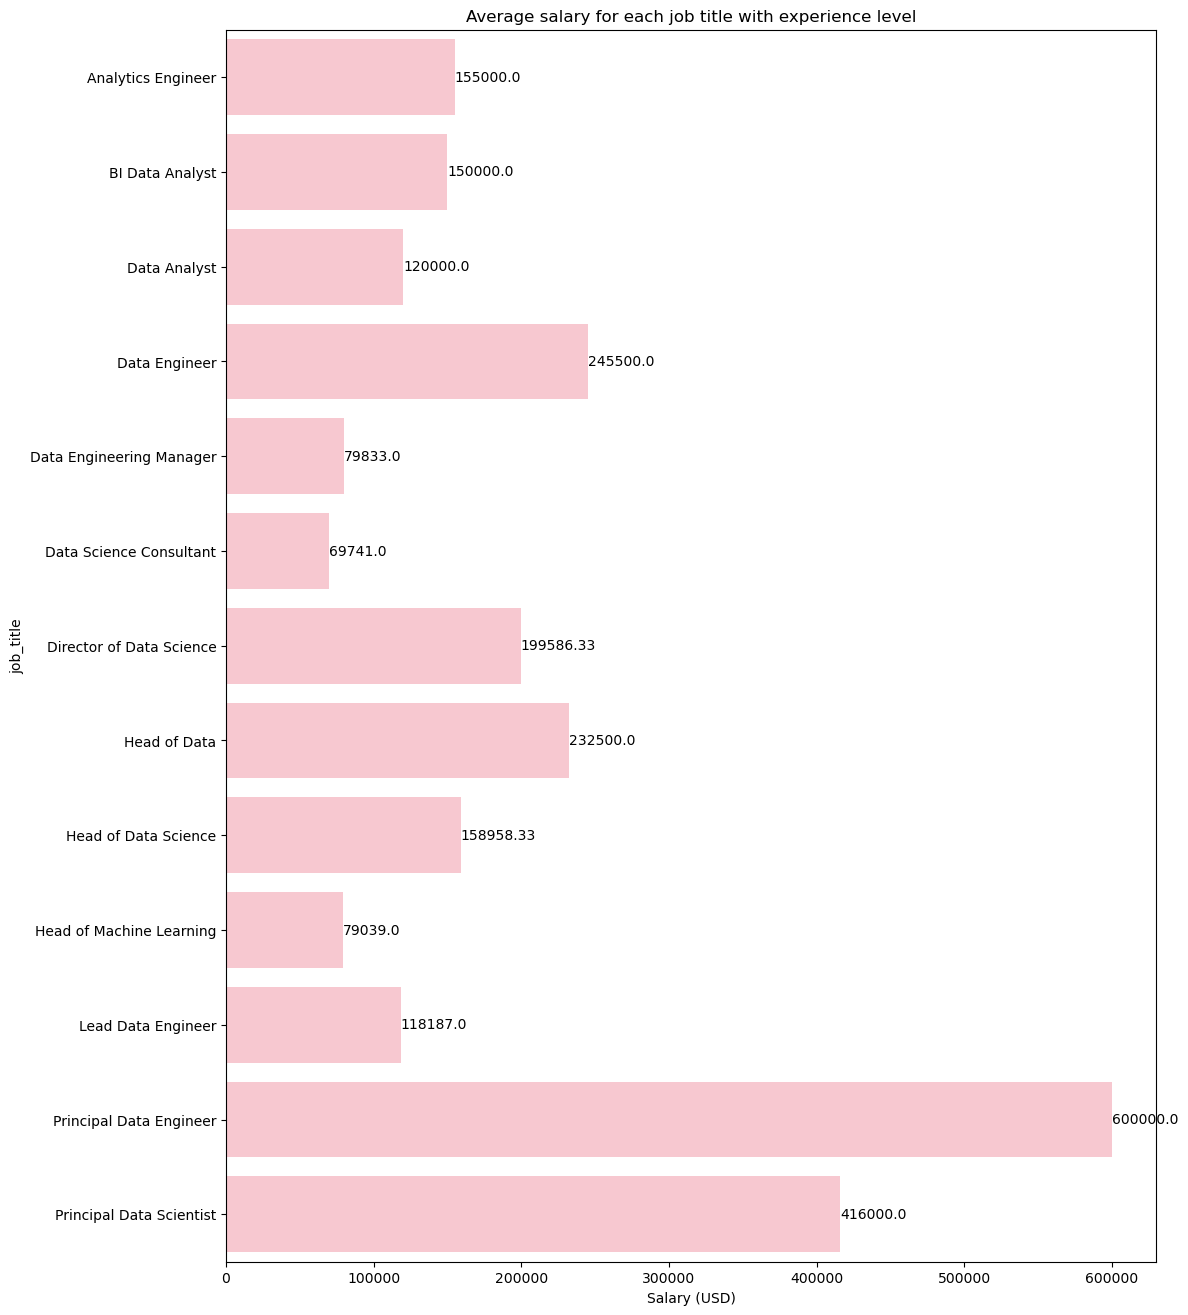

In [53]:
#What is the average salary for highest earning job titles working at expert level ?

# Get the data for expert level roles
data_expert = data[data['experience_level']=='Executive']

bar_plot('job_title',data_expert,"Average salary for each job title with experience level")


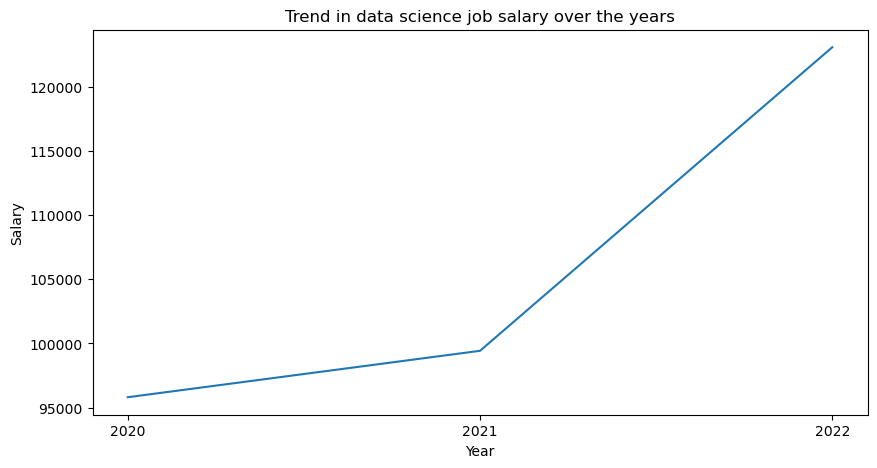

In [54]:
# Has salary of data science job roles increased over the passing years ?

data_year = data.groupby('work_year')['salary_in_usd'].mean()


plt.figure(figsize=(10,5))
ax = sns.lineplot(x=data_year.index,y=data_year.values)
ax.set_xticks([2020,2021,2022])
ax.set_xlabel('Year')
ax.set_ylabel('Salary')
ax.set_title('Trend in data science job salary over the years')
plt.show()


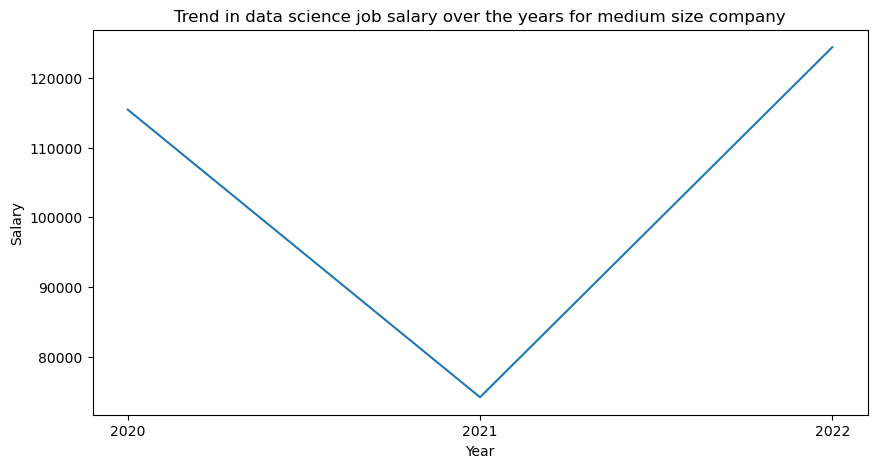

In [55]:
#What is the trend of salaries paid by medium size companies over the passing years ?
data_M = data[data['company_size']=='Medium']
data_M_year = data_M.groupby('work_year')['salary_in_usd'].mean()


plt.figure(figsize=(10,5))
ax = sns.lineplot(x=data_M_year.index,y=data_M_year.values)
ax.set_xticks([2020,2021,2022])
ax.set_xlabel('Year')
ax.set_ylabel('Salary')
ax.set_title('Trend in data science job salary over the years for medium size company')
plt.show()

. Medium size companies paid less to the employees in 2021 than in 2020.


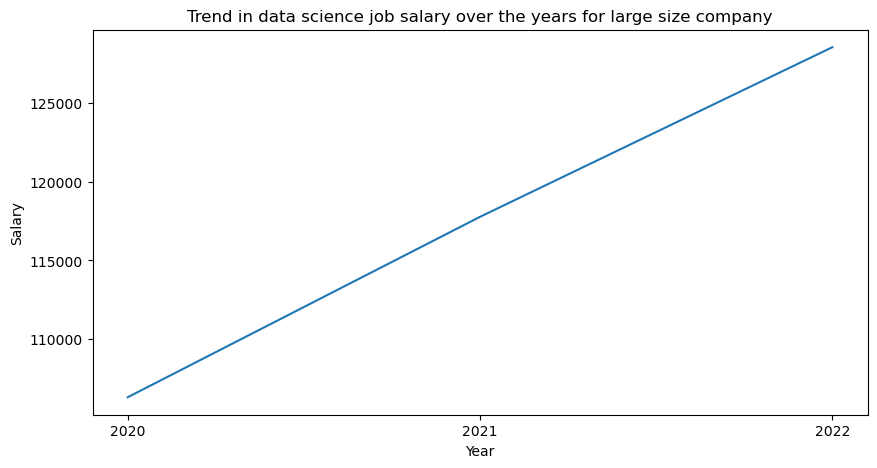

In [56]:

data_L = data[data['company_size']=='Large']
data_L_year = data_L.groupby('work_year')['salary_in_usd'].mean()

plt.figure(figsize=(10,5))
ax = sns.lineplot(x=data_L_year.index,y=data_L_year.values)
ax.set_xticks([2020,2021,2022])
ax.set_xlabel('Year')
ax.set_ylabel('Salary')
ax.set_title('Trend in data science job salary over the years for large size company')
plt.show()



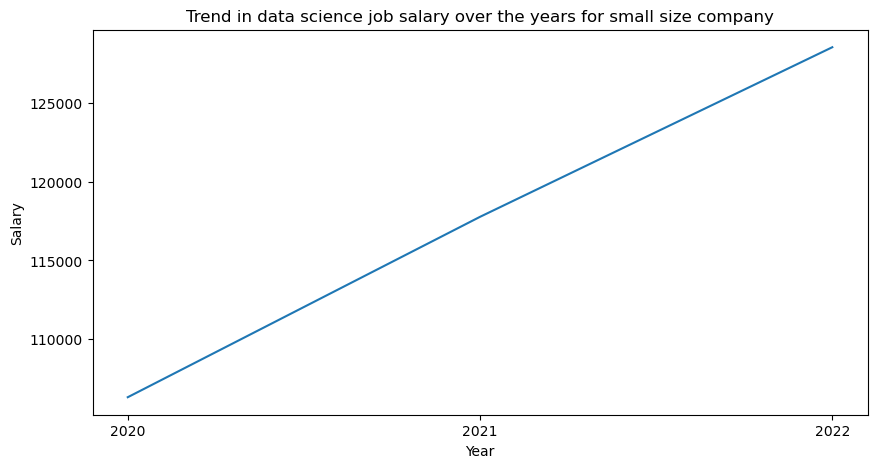

In [57]:
data_S = data[data['company_size']=='Small']
data_S_year = data_S.groupby('work_year')['salary_in_usd'].mean()

plt.figure(figsize=(10,5))
ax = sns.lineplot(x=data_L_year.index,y=data_L_year.values)
ax.set_xticks([2020,2021,2022])
ax.set_xlabel('Year')
ax.set_ylabel('Salary')
ax.set_title('Trend in data science job salary over the years for small size company')
plt.show()